In [5]:
from pathlib import Path
import sys

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.datasets import TUDataset

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import pytorch_to_networkx, networkx_to_igraph, DatasetPT
from src.graph_analysis import analyze_single_graph, calculate_annd_error, calculate_moments_error, calculate_eccentricity_error
from notebooks.visualization_utils import plot_graph, plot_annd, plot_eccentricity, save_figure_pdf
from src.anndg.graph_generator import generate_graph
from src.generate_datasets import generate_graph as generate_graph_by_method

In [6]:
DATASET = "DHFR"
IDX = 37

try:
    dataset = DatasetPT(PROJECT_ROOT / "data" / DATASET / f"{DATASET}_original.pt")
except:
    dataset = TUDataset(PROJECT_ROOT / "data", name=DATASET)

GRAPH_NX = pytorch_to_networkx(dataset[IDX])
GRAPH_IG = networkx_to_igraph(GRAPH_NX)

In [7]:
# Analyze Original Graph
target_stats = analyze_single_graph(GRAPH_IG)

# # Generate and Analyze Synthetic Graph
# rng = np.random.default_rng(seed=40689061)
# GRAPH_SYNTH_NX, info = generate_graph(target_stats, rng=rng, debug=True, replicate_eccentricity=True)
# GRAPH_SYNTH_IG = networkx_to_igraph(GRAPH_SYNTH_NX)
# obtained_stats = analyze_single_graph(GRAPH_SYNTH_IG)

# # Combined Visualization
# fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# # Row 1: Graph Structures
# plot_graph(graph=GRAPH_NX, ax=axes[0, 0], dataset_name=f"{DATASET} (Original)", graph_index=IDX)
# plot_graph(graph=GRAPH_SYNTH_NX, ax=axes[0, 1], dataset_name=f"{DATASET} (Synthetic)", graph_index=IDX)

# # Row 2: Topological Metrics
# plot_annd(annd_values=info['best_annd'], ax=axes[1, 0], title="ANND Profile", target_graph=GRAPH_NX)
# if 'best_eccentricity' in info:
#     plot_eccentricity(ecc_values=info['best_eccentricity'], ax=axes[1, 1], title="Eccentricity Profile", target_graph=GRAPH_NX)
# else:
#     axes[1, 1].axis('off')

# plt.tight_layout()
# plt.show()

# print(f"\n" + "="*70)
# print(f"{'TOPOLOGICAL STATISTIC':<25} | {'ORIGINAL':<12} | {'SYNTHETIC':<12} | {'DELTA':<10}")
# print("-" * 70)

# # Scalar metrics comparison
# scalar_metrics = ['assortativity', 'modularity', 'clustering', 'efficiency', 'diameter']
# for m in scalar_metrics:
#     orig = target_stats.get(m, 0.0)
#     synth = obtained_stats.get(m, 0.0)
#     delta = abs(orig - synth)
#     print(f"{m.capitalize():<25} | {orig:>12.4f} | {synth:>12.4f} | {delta:>10.4f}")

# # ANND comparison
# print("-" * 70)
# print(f"{'ANND Bin 0':<25} | {target_stats['annd'][0]:>12.4f} | {info['best_annd'][0]:>12.4f} | {abs(target_stats['annd'][0] - info['best_annd'][0]):>10.4f}")
# print(f"{'ANND Bin 1':<25} | {target_stats['annd'][1]:>12.4f} | {info['best_annd'][1]:>12.4f} | {abs(target_stats['annd'][1] - info['best_annd'][1]):>10.4f}")
# print(f"{'ANND Bin 2':<25} | {target_stats['annd'][2]:>12.4f} | {info['best_annd'][2]:>12.4f} | {abs(target_stats['annd'][2] - info['best_annd'][2]):>10.4f}")
# print(f"{'ANND Bin 3':<25} | {target_stats['annd'][3]:>12.4f} | {info['best_annd'][3]:>12.4f} | {abs(target_stats['annd'][3] - info['best_annd'][3]):>10.4f}")
# print("-" * 70)

# annd_error = calculate_annd_error(info['best_annd'], target_stats['annd'])
# if 'best_eccentricity' in info:
#     ecc_error = calculate_eccentricity_error(info['best_eccentricity'], target_stats['eccentricity'])
# else:
#     ecc_error = np.nan
# moments_error = calculate_moments_error(target_stats['degree_moments'], obtained_stats['degree_moments'])
# diameter_error = abs(obtained_stats['diameter'] - target_stats['diameter']) / target_stats['diameter'] if target_stats['diameter'] > 0 else 0.0

# print(f"\n{'STRUCTURAL ERROR SUMMARY':<25} | {'VALUE':<12}")
# print("-" * 40)
# print(f"{'Moments Error':<25} | {moments_error:>12.4f}")
# print(f"{'ANND Error':<25} | {annd_error:>12.4f}")
# print(f"{'Eccentricity Error':<25} | {ecc_error:>12.4f}")
# print(f"{'Diameter Error':<25} | {diameter_error:>12.4f}")
# print("="*70 + "\n")

Detected invariant statistics at indices [6, 7]. These parameters will be fixed during optimization.
Covariance matrix inversion failed. Falling back to pseudo-inverse.
Covariance matrix inversion failed. Falling back to pseudo-inverse.
Covariance matrix inversion failed. Falling back to pseudo-inverse.
Covariance matrix inversion failed. Falling back to pseudo-inverse.
Covariance matrix inversion failed. Falling back to pseudo-inverse.
Covariance matrix inversion failed. Falling back to pseudo-inverse.
Covariance matrix inversion failed. Falling back to pseudo-inverse.
Covariance matrix inversion failed. Falling back to pseudo-inverse.


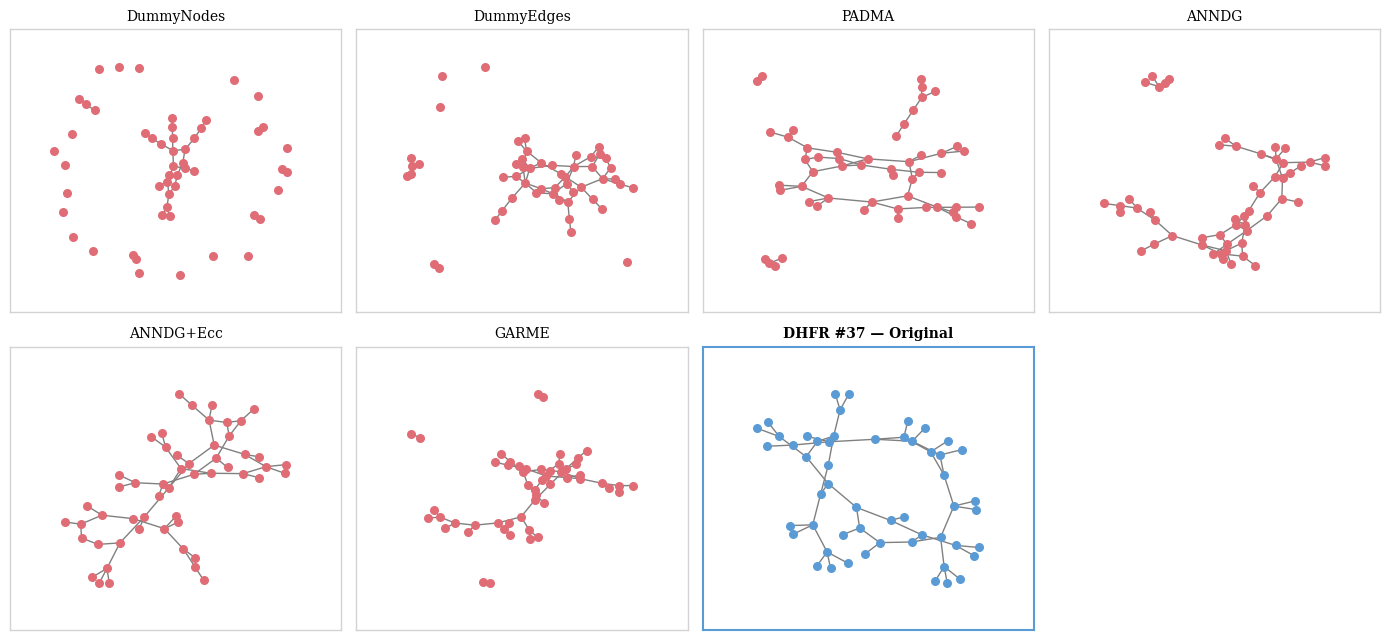

[save_figure_pdf] Saved → /home/amarigo/syn_bench_gnn2/syn_bench_gnn/single_generation_example.pdf


PosixPath('/home/amarigo/syn_bench_gnn2/syn_bench_gnn/single_generation_example.pdf')

In [ ]:
# Generate one synthetic graph per method and display alongside the original.
METHODS = ["dummyNodes", "dummyEdges", "padma", "anndg", "anndgE", "ergm"]
METHOD_LABELS = {
    "dummyNodes": "DummyNodes",
    "dummyEdges": "DummyEdges",
    "padma":      "PADMA",
    "anndg":      "ANNDG",
    "anndgE":     "ANNDG+Ecc",
    "ergm":       "GARME",
}

# Set font family to Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

rng_cmp = np.random.default_rng(seed=99887766)

# Build target_stats once (reuse the already-computed one from Cell 2)
target_stats_for_gen = dict(target_stats)
target_stats_for_gen["observed_nx"] = GRAPH_NX  # needed by pdd / ergm

generated = {}  # method -> nx.Graph
for method in METHODS:
    try:
        G_gen, _ = generate_graph_by_method(target_stats_for_gen, method=method, rng=rng_cmp)
        generated[method] = G_gen
    except Exception as exc:
        print(f"[WARNING] {method} failed: {exc}")
        generated[method] = nx.empty_graph(target_stats_for_gen.get("n_nodes", 1))

# 2 rows x 4 cols: row 0 → dummyNodes, dummyEdges, padma, anndg
#                  row 1 → anndgE, ergm, original, [hidden]
SYNTH_COLOR = "#E06C75"
ORIG_COLOR  = "#5B9BD5"

fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))

plot_order = ["dummyNodes", "dummyEdges", "padma", "anndg", "anndgE", "ergm"]
for ax, method in zip(axes.flat, plot_order):
    G = generated[method]
    label = METHOD_LABELS[method]
    plot_graph(graph=G, ax=ax, dataset_name=label, graph_index=IDX, node_color=SYNTH_COLOR)
    ax.set_title(label, fontsize=15)

    # Frame
    ax.axis("on")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.margins(0.18)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#d3d3d3')
        spine.set_linewidth(1.0)

# 7th subplot (row 1, col 2): original graph
ax_orig = axes[1, 2]
plot_graph(graph=GRAPH_NX, ax=ax_orig, dataset_name=DATASET, graph_index=IDX, node_color=ORIG_COLOR)
ax_orig.set_title(f"{DATASET} #{IDX} — Original", fontsize=15, fontweight="bold")

ax_orig.axis("on")
ax_orig.set_xticks([])
ax_orig.set_yticks([])
ax_orig.margins(0.18)
for spine in ax_orig.spines.values():
    spine.set_visible(True)
    spine.set_color('#5B9BD5')
    spine.set_linewidth(1.5)

# Hide the unused 8th cell (row 1, col 3)
axes[1, 3].axis("off")

plt.tight_layout()
plt.show()
save_figure_pdf(fig, axes, PROJECT_ROOT / "single_generation_example.pdf")